# SHAP — Drivers structurels du prix au m²

Source : `db_ai_house.rpt_shap_commune` — une ligne par commune, moyennée 2021-2025.  
Modèle : LightGBM avec `code_departement` en catégorielle native.  
Objectif : expliquer POURQUOI une commune est chère — géographie, type de bien, énergie, construction, marché du neuf.  
Pas de lag features : on veut les drivers structurels, pas l'autocorrélation temporelle.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv()
print('imports OK')

imports OK


## 1. Chargement des données

In [2]:
client = clickhouse_connect.get_client(
    host=os.environ['CLICKHOUSE_HOST'],
    port=int(os.environ.get('CLICKHOUSE_PORT', '8123')),
    username=os.environ['CLICKHOUSE_USER'],
    password=os.environ['CLICKHOUSE_PASSWORD'],
)

df = client.query_df("""
    SELECT *
    FROM db_ai_house.rpt_shap_commune
""")

print(f"{len(df):,} communes chargées")
df.describe()

13,931 communes chargées


,prix_m2_med,prix_m2_moy,prix_m2_q25,prix_m2_q75,nb_transactions_total,pct_appt,pct_maison,surface_moy,nb_pieces_moy,transactions_par_mois,...,nb_logements_sociaux,pct_passoires_ls,surface_moy_ls,prix_m2_neuf_dept,stock_neuf_dept,delai_ecoulement_dept,taux_reservation_dept,nb_mises_en_vente_dept,annee_min,annee_max
count,13931.000000,13931.000000,13931.000000,13931.000000,13931.000000,13931.000000,13931.000000,13931.000000,13931.000000,13931.000000,...,13931.000000,13931.000000,11639.000000,13762.000000,13841.000000,13764.000000,13691.000000,13841.0,13931.000000,13931.000000
mean,2216.909124,2386.975738,1729.106310,2731.720121,198.501400,12.943342,82.346795,100.327600,3.740162,3.309080,...,1.369248,1.718821,72.666535,3837.004723,1611.193411,9.407621,108.568797,1075.867856,2021.001005,2024.995980
std,1060.690012,1123.610819,877.144666,1289.062504,719.734405,18.561088,20.764113,58.968134,0.560684,11.995186,...,2.452691,9.204383,12.558969,1398.010074,1600.855301,11.849286,71.125958,1133.683955,0.047919,0.067663
min,711.000000,812.000000,580.000000,915.000000,20.000000,0.000000,0.000000,31.000000,0.500000,0.300000,...,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,14.300000,0.0,2021.000000,2022.000000
25%,1521.000000,1659.000000,1131.000000,1935.000000,31.000000,0.000000,76.000000,88.500000,3.400000,0.500000,...,0.000000,0.000000,65.000000,3552.000000,338.000000,5.800000,73.500000,147.0,2021.000000,2025.000000
50%,1979.000000,2104.000000,1529.000000,2408.000000,55.000000,4.800000,90.400000,96.900000,3.800000,0.900000,...,0.000000,0.000000,72.300000,4019.000000,983.000000,7.300000,93.300000,669.0,2021.000000,2025.000000
75%,2594.000000,2769.500000,2059.000000,3133.000000,136.000000,17.200000,96.300000,106.400000,4.100000,2.300000,...,2.000000,0.000000,79.700000,4555.000000,2681.000000,9.200000,116.200000,1548.0,2021.000000,2025.000000
max,14250.000000,14512.000000,11724.000000,19521.000000,28137.000000,96.400000,100.000000,5601.100000,7.400000,469.000000,...,16.000000,100.000000,186.000000,13310.000000,6649.000000,105.000000,465.000000,5775.0,2025.000000,2025.000000


## 2. Préparation des features

In [3]:
TARGET = 'prix_m2_med'

# Identifiants et variantes de la cible exclus
EXCLUDE = [
    'code_commune',
    'prix_m2_moy', 'prix_m2_q25', 'prix_m2_q75',
    'annee_min', 'annee_max',
    TARGET,
]

FEATURES = [c for c in df.columns if c not in EXCLUDE]

X = df[FEATURES].copy()
y = df[TARGET]

# code_departement en catégorielle — LightGBM gère nativement
X['code_departement'] = X['code_departement'].astype('category')

# Supprimer les lignes avec trop de nulls
mask = X.isnull().mean(axis=1) < 0.5
X, y = X[mask], y[mask]

print(f"{len(FEATURES)} features | {len(X):,} communes")
print(X.dtypes.value_counts())

23 features | 13,930 communes
float64     16
uint64       3
Int64        3
category     1
Name: count, dtype: int64


## 3. Entraînement LightGBM

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=10,
    n_jobs=-1,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)],
)

y_pred = model.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f} €/m²")
print(f"R²   : {r2_score(y_test, y_pred):.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4169
[LightGBM] [Info] Number of data points in the train set: 11144, number of used features: 23
[LightGBM] [Info] Start training from score 2215.423995


[200]	valid_0's l2: 327295


[400]	valid_0's l2: 322236


MAE  : 365 €/m²
R²   : 0.696


## 4. Valeurs SHAP

In [5]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_test)
print(f"shap_values.shape : {shap_values.values.shape}")

shap_values.shape : (2786, 23)


## 5. Importance globale — Beeswarm
Chaque point = une commune. Couleur = valeur de la feature. Position X = impact sur le prix.

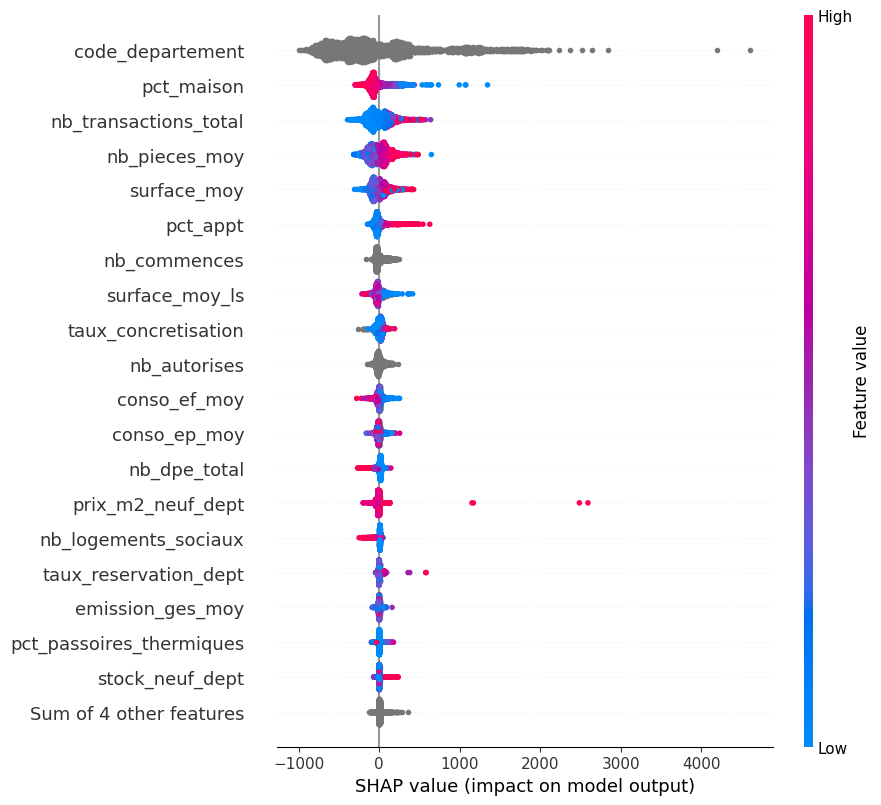

In [6]:
shap.plots.beeswarm(shap_values, max_display=20)

## 6. Importance globale — Bar chart

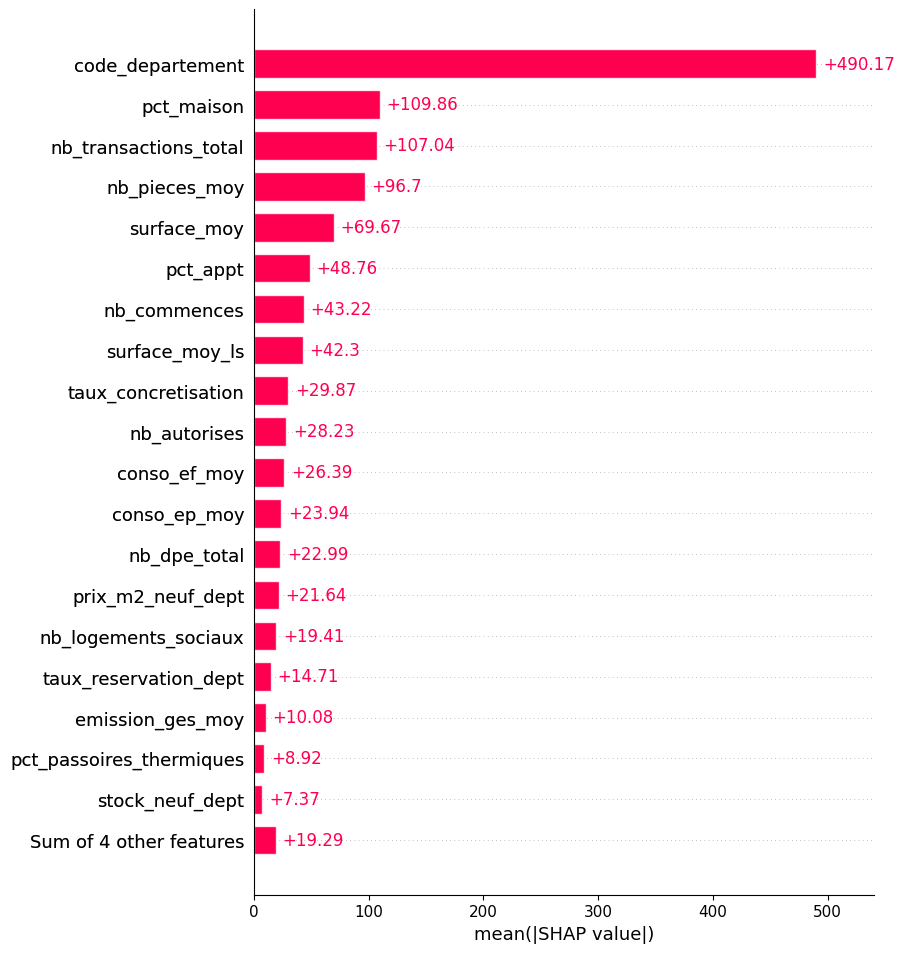

In [7]:
shap.plots.bar(shap_values, max_display=20)

## 7. Dependence plots — top 4 features
Relation non-linéaire entre la feature et son impact SHAP sur le prix.

Top 4 features: ['code_departement', 'pct_maison', 'nb_transactions_total', 'nb_pieces_moy']


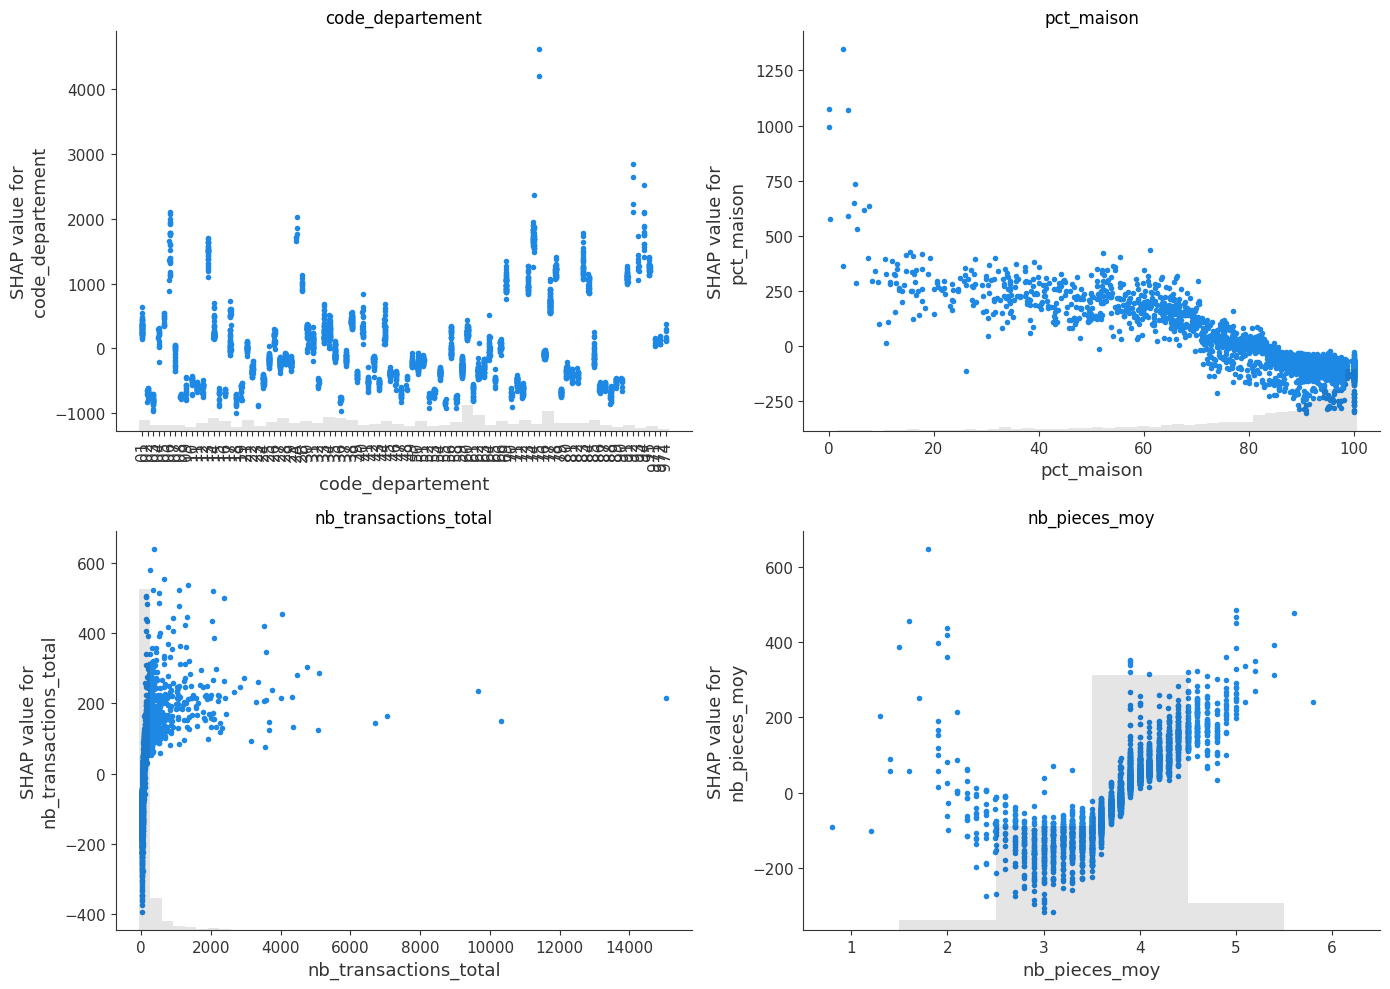

In [8]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_features  = [FEATURES[i] for i in np.argsort(mean_abs_shap)[::-1][:4]]
print('Top 4 features:', top_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), top_features):
    shap.plots.scatter(shap_values[:, feat], ax=ax, show=False)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

## 8. Waterfall — explication d'une commune
Change `code_commune_cible` pour inspecter n'importe quelle commune.

Commune 75056 pas dans le test set, affichage idx=0


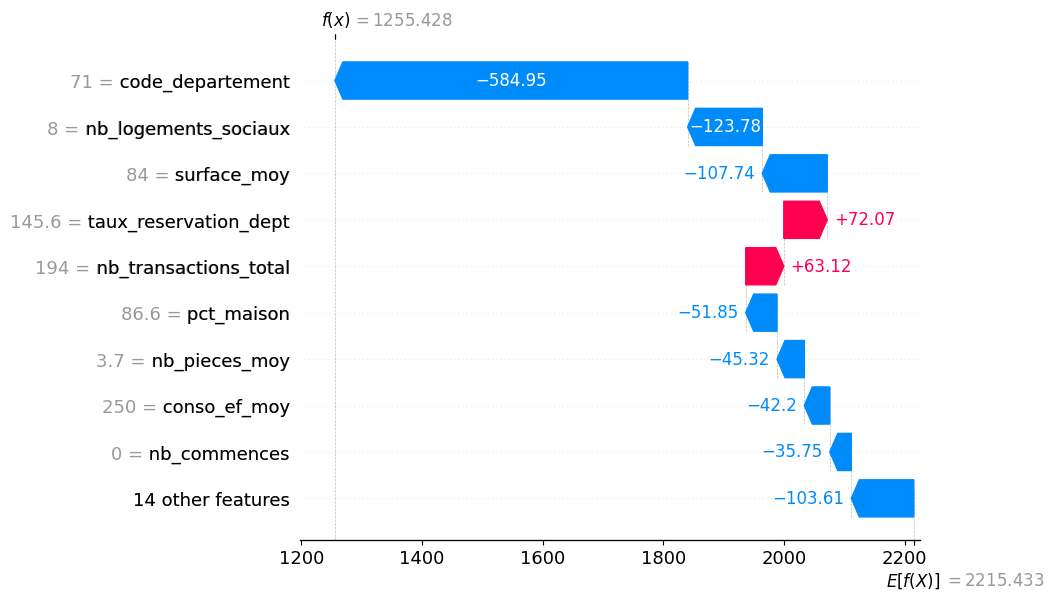

In [9]:
code_commune_cible = '75056'  # Paris — changer pour une autre commune

X_test_reset = X_test.reset_index(drop=True)
communes_test = df.loc[X_test.index, 'code_commune'].reset_index(drop=True)

mask_commune = communes_test == code_commune_cible
if mask_commune.any():
    idx = mask_commune.idxmax()
    shap.plots.waterfall(shap_values[idx])
else:
    print(f"Commune {code_commune_cible} pas dans le test set, affichage idx=0")
    shap.plots.waterfall(shap_values[0])

## 9. Impact du département (géographie)
SHAP moyen par département — visualise l'effet pur de la localisation.

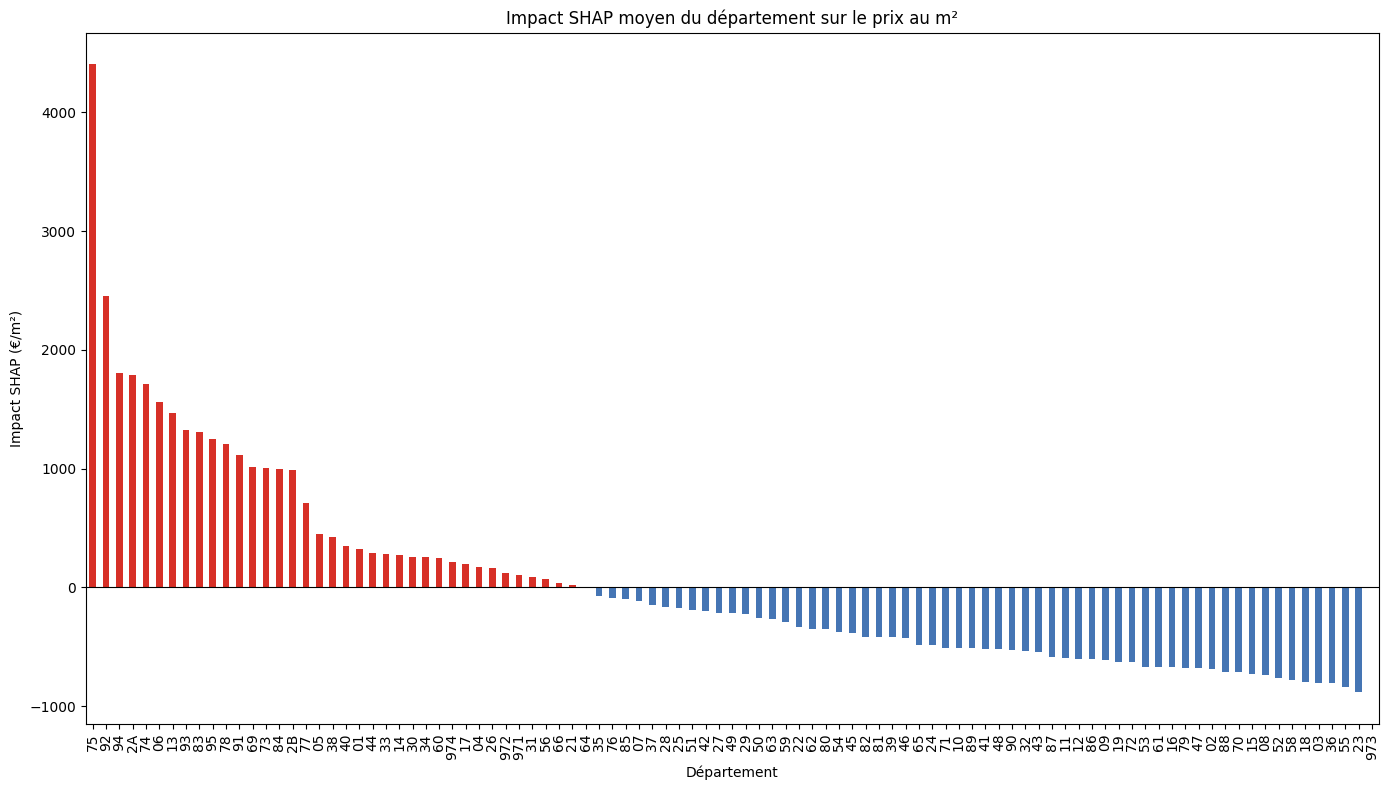

In [10]:
feat_idx = FEATURES.index('code_departement')
shap_dept = pd.DataFrame({
    'code_departement': X_test['code_departement'].values,
    'shap_value':       shap_values.values[:, feat_idx],
})

dept_impact = (
    shap_dept.groupby('code_departement')['shap_value']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#d73027' if v > 0 else '#4575b4' for v in dept_impact.values]
dept_impact.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Impact SHAP moyen du département sur le prix au m²')
ax.set_xlabel('Département')
ax.set_ylabel('Impact SHAP (€/m²)')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 10. Synthèse — Variables les plus explicatives du prix au m²

In [11]:
LABELS = {
    'code_departement':         'Département (localisation)',
    'pct_appt':                 '% appartements (urbanité)',
    'prix_m2_neuf_dept':        'Prix du neuf dans le département',
    'transactions_par_mois':    'Liquidité du marché (transactions/mois)',
    'nb_transactions_total':    'Volume total de transactions',
    'pct_maison':               '% maisons (caractère rural)',
    'surface_moy':              'Surface moyenne des biens vendus',
    'taux_reservation_dept':    'Taux de réservation logements neufs (tension)',
    'delai_ecoulement_dept':    "Délai d'écoulement du neuf (mois)",
    'stock_neuf_dept':          'Stock de logements neufs disponibles',
    'nb_mises_en_vente_dept':   'Mises en vente neuves (dept)',
    'pct_passoires_thermiques': '% passoires thermiques (F+G)',
    'conso_ep_moy':             'Consommation énergie primaire moyenne',
    'conso_ef_moy':             'Consommation énergie finale moyenne',
    'emission_ges_moy':         'Émissions GES moyennes',
    'nb_dpe_total':             'Nombre de DPE réalisés',
    'nb_pieces_moy':            'Nombre de pièces moyen',
    'nb_autorises':             'Logements autorisés (construction)',
    'nb_commences':             'Logements mis en chantier',
    'taux_concretisation':      'Taux de concrétisation (chantiers/permis)',
    'nb_logements_sociaux':     'Nombre de logements sociaux',
    'pct_passoires_ls':         '% passoires thermiques HLM',
    'surface_moy_ls':           'Surface moyenne logements sociaux',
}

mean_abs_shap  = np.abs(shap_values.values).mean(axis=0)
ranking = (
    pd.DataFrame({
        'feature':      FEATURES,
        'importance_shap': mean_abs_shap,
    })
    .sort_values('importance_shap', ascending=False)
    .reset_index(drop=True)
)
ranking.index += 1
ranking['label']   = ranking['feature'].map(LABELS)
ranking['impact_€/m²'] = ranking['importance_shap'].round(0).astype(int)
ranking['part_%']  = (ranking['importance_shap'] / ranking['importance_shap'].sum() * 100).round(1)

print("=" * 65)
print(f"{'Rang':<5} {'Variable':<40} {'Impact moy. (€/m²)':>18} {'Part':>6}")
print("=" * 65)
for i, row in ranking.iterrows():
    label = row['label'] if pd.notna(row['label']) else row['feature']
    print(f"{i:<5} {label[:40]:<40} {row['impact_€/m²']:>18,} {row['part_%']:>5.1f}%")
print("=" * 65)

Rang  Variable                                 Impact moy. (€/m²)   Part
1     Département (localisation)                              490  39.5%
2     % maisons (caractère rural)                             110   8.9%
3     Volume total de transactions                            107   8.6%
4     Nombre de pièces moyen                                   97   7.8%
5     Surface moyenne des biens vendus                         70   5.6%
6     % appartements (urbanité)                                49   3.9%
7     Logements mis en chantier                                43   3.5%
8     Surface moyenne logements sociaux                        42   3.4%
9     Taux de concrétisation (chantiers/permis                 30   2.4%
10    Logements autorisés (construction)                       28   2.3%
11    Consommation énergie finale moyenne                      26   2.1%
12    Consommation énergie primaire moyenne                    24   1.9%
13    Nombre de DPE réalisés                       